In [12]:
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway
import matplotlib.pyplot as plt

In [3]:
benin = pd.read_csv('data/benin-malanville_clean.csv')
sierra = pd.read_csv('data/sierraleone-bumbuna_clean.csv')
togo = pd.read_csv('data/togo-dapaong_qc_clean.csv')


In [4]:
benin['Country'] = 'Benin'
sierra['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'

df_all = pd.concat([benin, sierra, togo], ignore_index=True)

In [5]:
df_all.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,...,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,Month,Country
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,...,122.1,0.0,998,0,0.0,26.3,26.2,NaN,8.0,Benin
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,...,0.0,0.0,998,0,0.0,26.3,26.2,NaN,8.0,Benin
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,...,124.6,1.5,997,0,0.0,26.4,26.2,NaN,8.0,Benin
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,...,120.3,1.3,997,0,0.0,26.4,26.3,NaN,8.0,Benin
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,...,113.2,1.0,997,0,0.0,26.4,26.3,NaN,8.0,Benin


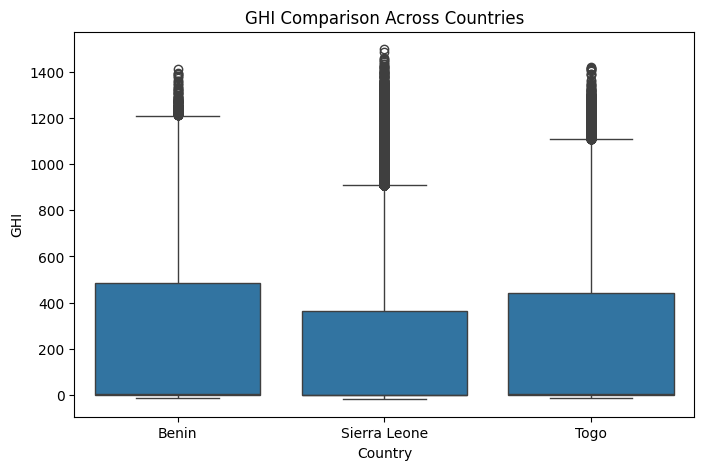

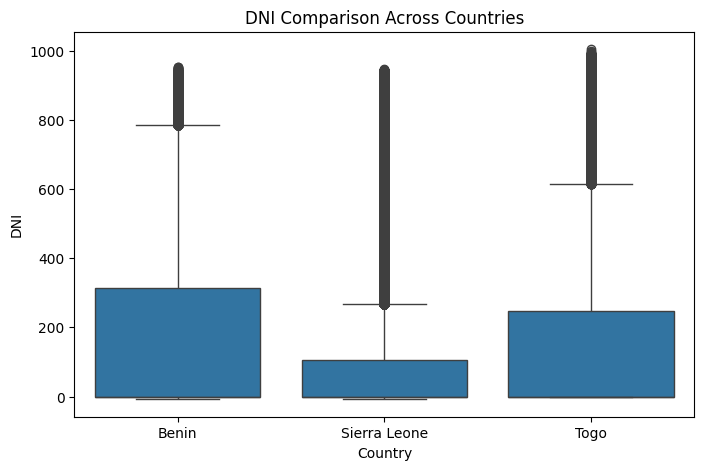

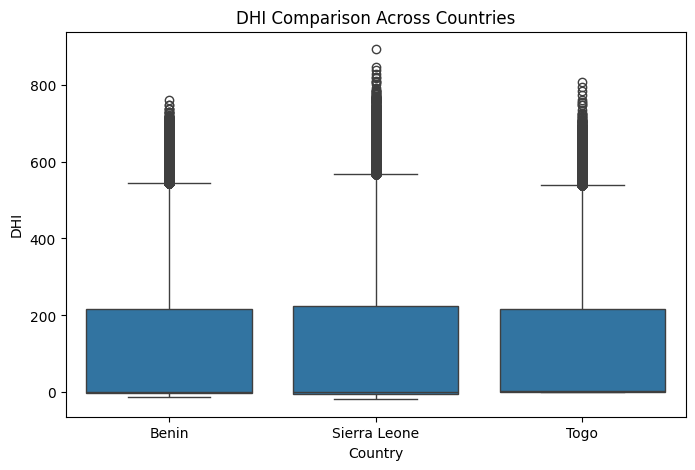

In [8]:
for metric in ['GHI', 'DNI', 'DHI']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_all, x='Country', y=metric)
    plt.title(f'{metric} Comparison Across Countries')
    plt.show()


In [9]:
summary_stats = df_all.groupby('Country')[['GHI', 'DNI', 'DHI']].agg(['mean', 'median', 'std'])
summary_stats


GHI                            DNI                     \
                    mean median         std        mean median         std   
Country                                                                      
Benin         240.559452    1.8  331.131327  167.187516   -0.1  261.710501   
Sierra Leone  201.957515    0.3  298.495150  116.376337   -0.1  218.652659   
Togo          230.555040    2.1  322.532347  151.258469    0.0  250.956962   

                     DHI                     
                    mean median         std  
Country                                      
Benin         115.358961    1.6  158.691074  
Sierra Leone  113.720571   -0.1  158.946032  
Togo          116.444352    2.5  156.520714

In [13]:
f_stat, p = f_oneway(benin['GHI'], sierra['GHI'], togo['GHI'])
print(f"P-value: {p}")

P-value: 0.0


<Axes: title={'center': 'Average GHI by Country'}, xlabel='Country'>

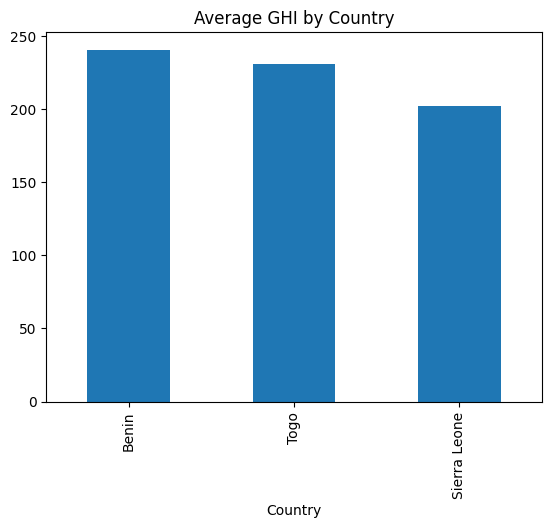

In [14]:
df_all.groupby('Country')['GHI'].mean().sort_values(ascending=False).plot(kind='bar', title='Average GHI by Country')
